# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.

In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:

# cantidad de nulos para users
print(users.isna().sum())
print()
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Diagnóstico de valores nulos**

**Dataset users:**
- La columna **city** presenta 469 valores nulos (11.725%). Debido a que el porcentaje se encuentra entre el 5% y el 30%, es recomendable investigar la causa de los valores faltantes y evaluar una estrategia de imputación o mantenerlos como nulos si no es posible recuperarlos.
- La columna **churn_date** presenta 3534 valores nulos (88.35%). Este comportamiento es esperado, ya que los usuarios que continúan activos no tienen una fecha de cancelación registrada. Por ello, estos valores no deben imputarse ni eliminarse, sino conservarse como información válida.
  
**Dataset usage:**
- La columna **date** presenta 50 valores nulos (0.125%). Al ser un porcentaje muy bajo, estos registros pueden imputarse si es posible recuperar la información o eliminarse sin afectar significativamente el análisis.
- La columna **duration** presenta 22076 valores nulos (55.19%). Estos valores son esperados porque únicamente las llamadas tienen duración, mientras que los mensajes no. No se recomienda imputarlos.
- La columna **length** presenta 17896 valores nulos (44.74%). Estos valores también son esperados, ya que únicamente los mensajes tienen longitud y las llamadas no. Por lo tanto, deben mantenerse como nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` contiene identificadores consecutivos entre 10000 y 13999. No se observan valores inválidos o inconsistencias.
- La columna `age` presenta un valor mínimo de -999, el cual corresponde a un valor sentinel y no representa una edad válida. Este valor deberá reemplazarse por un valor nulo (NaN) para su posterior tratamiento durante la limpieza de datos.

In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` presentan identificadores consecutivos dentro del rango esperado. No se identifican valores fuera de rango, registros inválidos ni inconsistencias aparentes.
- Las columnas `duration` y `length` presentan valores dentro de rangos esperados (0 a 120 para duration y 0 a 1490 para length). No se identifican valores sentinel como -999 o 999; sin embargo, existen registros con valor 0, los cuales podrían corresponder a llamadas sin duración registrada, mensajes vacíos o posibles errores de captura, por lo que se recomienda revisarlos durante la etapa de limpieza.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']


for col in columnas_user:
    print(f"\n===== {col} =====")
    print("Valores únicos:", users[col].nunique(dropna=False))
    print(users[col].value_counts(dropna=False))




===== city =====
Valores únicos: 8
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

===== plan =====
Valores únicos: 2
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` presenta ocho valores únicos, incluyendo 469 valores nulos y 96 registros con el valor "?", el cual corresponde a un valor inválido (sentinel) y deberá reemplazarse por NaN. Asimismo, se observan abreviaturas como CDMX, GDL y MTY, por lo que podría ser conveniente estandarizar los nombres de las ciudades.
- La columna `plan` presenta únicamente las categorías Basico y Premium, por lo que no se identifican valores inválidos ni inconsistencias.

In [16]:
# explorar columna categórica de usage
columnas_usage = ['type'] # completa el código

for col in columnas_usage:
    print(f"\n===== {col} =====")
    print("Valores únicos:", usage[col].nunique(dropna=False))
    print(usage[col].value_counts(dropna=False))




===== type =====
Valores únicos: 2
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` presenta únicamente dos categorías, text y call, las cuales corresponden a los tipos de actividad registrados en el dataset. No se identifican valores inválidos, categorías inesperadas ni inconsistencias.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

**Diagnóstico** 
Se identificaron valores sentinel en las columnas `age` y `city` del dataset users. En `age` se encontró el valor -999, el cual no corresponde a una edad válida y deberá reemplazarse por NaN. Asimismo, en `city` se identificó el valor "?", que representa una ciudad desconocida o inválida y también deberá sustituirse por NaN. En las columnas `plan` y `type`, así como en las variables numéricas del dataset usage, no se identificaron valores sentinel como -999 o 999, por lo que no se requieren acciones adicionales sobre estos campos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")# completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage["date"] = pd.to_datetime(usage["date"], errors="coerce")

In [19]:
# Revisar los años presentes en `reg_date` de users
print(users["reg_date"].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date` se identifican registros correspondientes a los años 2022, 2023 y 2024, que se encuentran dentro del periodo esperado. Sin embargo, también se detectaron 40 registros del año 2026, los cuales representan fechas fuera del rango establecido para el análisis y deberán investigarse para determinar si corresponden a errores de captura y corregirse o excluirse durante la limpieza de los datos.

In [20]:
# Revisar los años presentes en `date` de usage
print(usage["date"].dt.year.value_counts().sort_index())


2024.0    39950
Name: date, dtype: int64


En `date` únicamente se identifican registros correspondientes al año 2024, el cual se encuentra dentro del periodo definido para el análisis. No se observan fechas fuera del rango esperado, por lo que esta columna no presenta inconsistencias relacionadas con el año de registro.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Diagnóstico**

- La columna `reg_date` presenta registros correspondientes a los años 2022, 2023 y 2024, además de 40 registros del año 2026, los cuales se encuentran fuera del periodo definido para el análisis (hasta 2024) y deberán revisarse para determinar si corresponden a errores de captura; de confirmarse, se recomienda corregirlos o excluirlos del análisis. 
- El **dataset usage** contiene 40 000 registros; sin embargo, al revisar la columna `date` únicamente se contabilizan 39 950 registros del año 2024, ya que los 50 registros restantes corresponden a valores nulos (NaT) y no son considerados por **value_counts()**. En consecuencia, no se identifican años fuera del rango esperado en esta columna, aunque los valores nulos deberán tratarse durante la etapa de limpieza de datos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users["city"].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [23]:
# Marcar fechas futuras como NA para reg_date
users["reg_date"] = users["reg_date"].where(
    users["reg_date"].dt.year <= 2024,
    pd.NaT
)

# Verificar cambios
users["reg_date"].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration

usage.groupby("type")["duration"].apply(lambda x: x.isna().value_counts())

type       
call  False    17908
text  True     22076
      False       16
Name: duration, dtype: int64

In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby("type")["length"].apply(lambda x: x.isna().value_counts())

type       
call  True     17896
      False       12
text  False    22092
Name: length, dtype: int64

**Diagnóstico**
- En la columna `duration` La mayoría de los valores nulos dependen de la variable `type`, ya que las llamadas (call) registran una duración, mientras que los mensajes (text) no. Sin embargo, se identificaron 16 registros de tipo text con una duración registrada, lo que representa una posible inconsistencia que deberá revisarse durante la limpieza. Por ello, no se recomienda imputar los valores nulos de esta columna.
- En la columna `length` la mayoría de los valores nulos también dependen de la variable `type`, debido a que los mensajes (text) registran una longitud y las llamadas (call) no. No obstante, se encontraron 12 registros de tipo call con una longitud registrada, lo que constituye una posible inconsistencia que deberá investigarse. En consecuencia, los valores nulos de esta columna deben conservarse, ya que corresponden a la estructura del dataset y no a datos faltantes que requieran imputación.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg.columns = [
    "user_id",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
user_profile[["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [31]:
import numpy as np
# Número de bins según la regla de Sturges
n = len(user_profile)
bins = int(np.ceil(1 + 3.322 * np.log10(n)))
#bins = 10
print("Número de bins:", bins)

Número de bins: 13


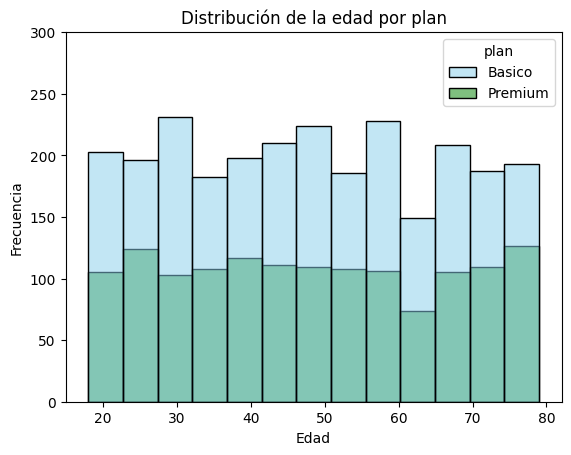

In [32]:
# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    bins=bins,
    multiple="layer",
    alpha=0.5,
    palette=["skyblue", "green"]
)

plt.title("Distribución de la edad por plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.ylim(0, 300)   
plt.show()

💡Insights: 
- No se observa un patrón claro entre la edad de los usuarios y el tipo de plan contratado. Las distribuciones de edad para los planes Básico y Premium son similares y abarcan prácticamente el mismo rango de edades (18 a 79 años). Asimismo, la distribución es aproximadamente uniforme, sin un sesgo evidente hacia la derecha o la izquierda.

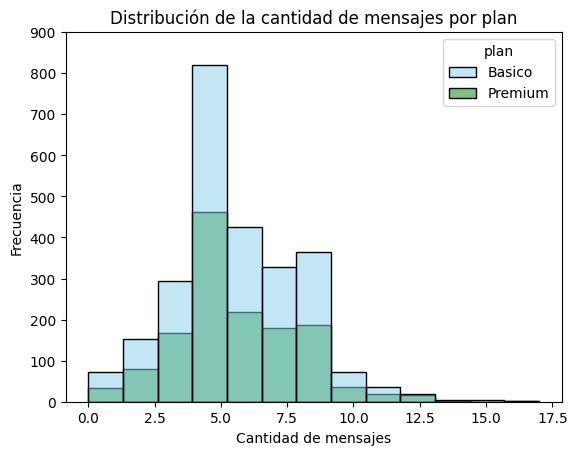

In [33]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    bins=bins,
    multiple="layer",
    alpha=0.5,
    palette=["skyblue", "green"]
)

plt.title("Distribución de la cantidad de mensajes por plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.ylim(0, 900)

plt.show()

💡Insights: 
- La mayor concentración de usuarios de ambos planes se encuentra entre 4 y 8 mensajes, con un máximo alrededor de 4–5 mensajes. No se observa una diferencia clara en el comportamiento de envío de mensajes entre los planes Básico y Premium; la principal diferencia en las frecuencias se debe a que el plan Básico cuenta con un mayor número de usuarios. Asimismo, la distribución presenta un sesgo hacia la derecha, debido a que pocos usuarios registran cantidades elevadas de mensajes.

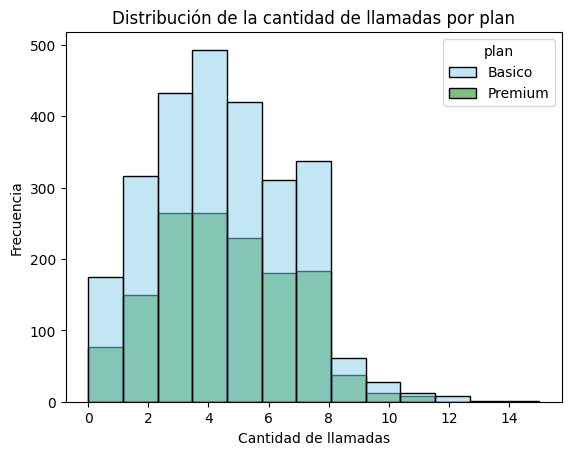

In [34]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    bins=bins,
    multiple="layer",
    alpha=0.5,
    palette=["skyblue", "green"]
)

plt.title("Distribución de la cantidad de llamadas por plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")

plt.show()


💡Insights: 
- La mayoría de los usuarios de ambos planes realiza entre 3 y 7 llamadas, con una mayor concentración alrededor de 4 o 5 llamadas. No se observa un patrón claro que indique que los usuarios de un plan realicen más llamadas que los del otro; la diferencia en las frecuencias se explica principalmente porque el plan Básico cuenta con un mayor número de usuarios. Asimismo, la distribución presenta un sesgo hacia la derecha, ya que pocos usuarios realizan una cantidad considerablemente mayor de llamadas.

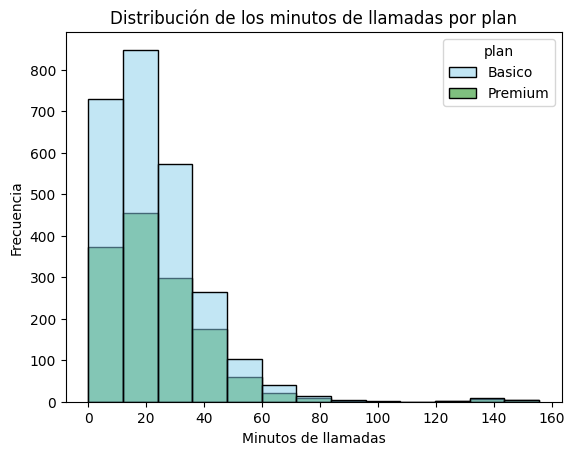

In [35]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    bins=bins,
    multiple="layer",
    alpha=0.5,
    palette=["skyblue", "green"]
)

plt.title("Distribución de los minutos de llamadas por plan")
plt.xlabel("Minutos de llamadas")
plt.ylabel("Frecuencia")

plt.show()

💡Insights: 
- La mayor concentración de usuarios de ambos planes registra entre 0 y 30 minutos de llamadas, mientras que el número de usuarios disminuye conforme aumenta el tiempo de conversación. No se observa un patrón claro que diferencie el consumo de minutos entre los planes Básico y Premium; la diferencia en las frecuencias responde principalmente al mayor número de usuarios del plan Básico. Asimismo, la distribución presenta un sesgo hacia la derecha, debido a que pocos usuarios concentran una cantidad elevada de minutos de llamadas, lo que sugiere la existencia de posibles valores atípicos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

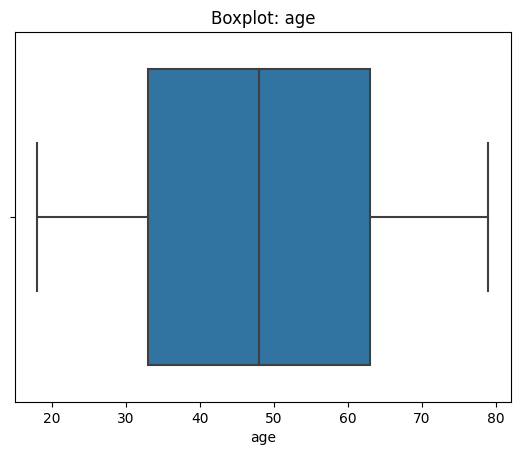

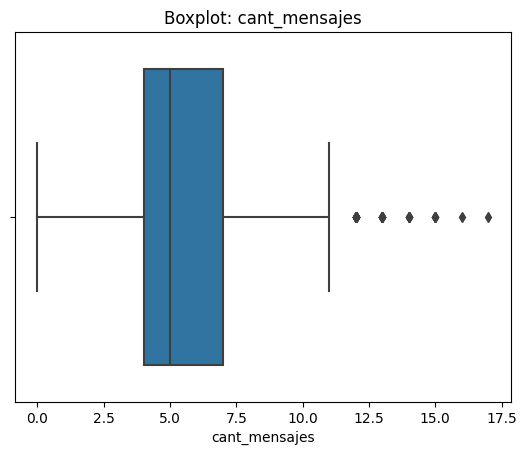

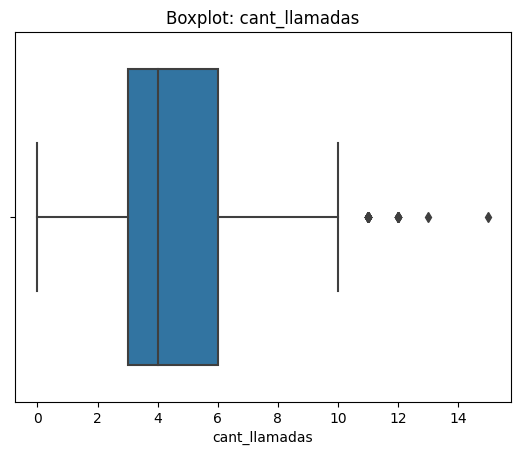

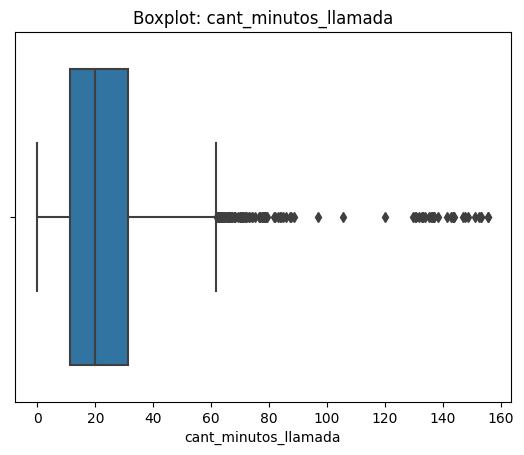

In [36]:
# Visualizando usando BoxPlot
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)

    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)

    plt.show()

💡Insights: 
- Age: No presenta valores atípicos. Todos los registros se encuentran dentro de los límites del boxplot, por lo que no se identifican edades inusuales que requieran revisión.
- cant_mensajes: Presenta valores atípicos únicamente en el extremo superior. Se observan pocos usuarios que envían una cantidad de mensajes considerablemente mayor que la mayoría, lo que indica una distribución con sesgo hacia la derecha.
- cant_llamadas: Presenta valores atípicos en el extremo superior. La mayoría de los usuarios realiza entre pocas y moderadas llamadas, mientras que un grupo reducido registra una cantidad de llamadas significativamente mayor.
- cant_minutos_llamada: Presenta una cantidad importante de valores atípicos en el extremo superior. La mayor parte de los usuarios acumula pocos minutos de llamadas, pero existe un grupo reducido con un consumo muy elevado, lo que evidencia una distribución fuertemente sesgada hacia la derecha.

In [37]:
# Calcular límites con el método IQR
columnas_limites = [
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

for col in columnas_limites:

    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)

    iqr = q3 - q1

    limite_superior = q3 + 1.5 * iqr

    print(f"{col}")
    print(f"Límite superior: {limite_superior:.2f}")
    print()



cant_mensajes
Límite superior: 11.50

cant_llamadas
Límite superior: 10.50

cant_minutos_llamada
Límite superior: 61.86



In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Se recomienda mantener los outliers, ya que, aunque el límite superior calculado mediante IQR es 11.50 y el valor máximo es 17, estos registros pueden representar usuarios con un mayor uso del servicio y no evidencian errores o valores imposibles.
- cant_llamadas: Se recomienda mantener los outliers, debido a que el límite superior es 10.50 y el valor máximo es 15. Estos valores son razonables dentro del contexto del uso de telefonía y podrían corresponder a usuarios con un mayor número de llamadas.
- cant_minutos_llamada: Se recomienda mantener los outliers, aunque el límite superior es 61.86 y el valor máximo alcanza 155.69 minutos. Estos registros representan usuarios con un consumo elevado de minutos, pero corresponden a un comportamiento posible y aportan información relevante para el análisis del uso del servicio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
# Crear columna grupo_uso
def clasificar_uso(row):

    if row["cant_llamadas"] < 5 and row["cant_mensajes"] < 5:
        return "Bajo uso"

    elif row["cant_llamadas"] < 10 and row["cant_mensajes"] < 10:
        return "Uso medio"

    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(clasificar_uso, axis=1)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
# Crear columna grupo_edad
def clasificar_edad(row):

    if row["age"] < 30:
        return "Joven"

    elif row["age"] < 60:
        return "Adulto"

    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(clasificar_edad, axis=1)

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

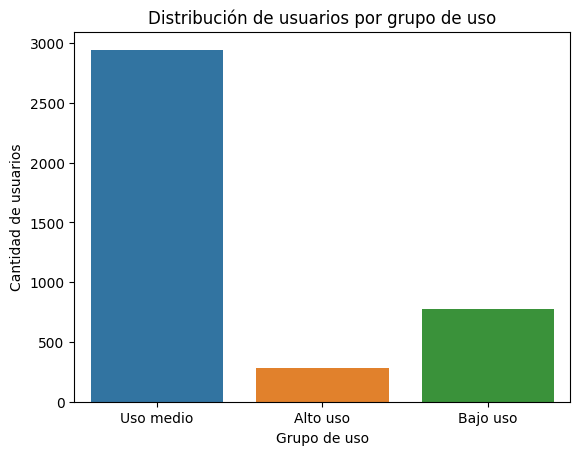

In [43]:

# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x="grupo_uso"
)

plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")

plt.show()

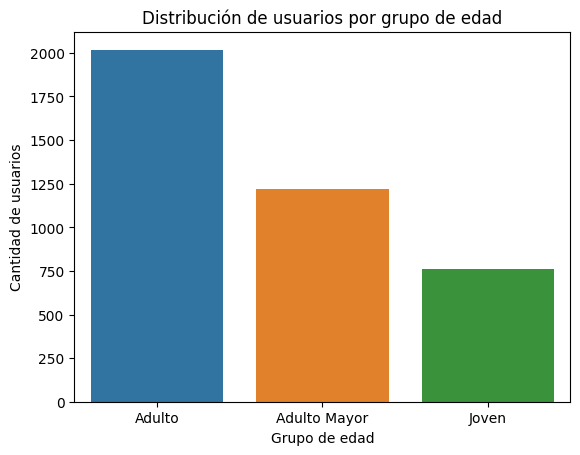

In [44]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x="grupo_edad"
)

plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificó un valor **sentinel** en la columna `age`, donde la edad `-999` fue reemplazada por la mediana para evitar sesgos en el análisis.
- La columna `city` presentó **96 registros** con el valor `"?"`, los cuales fueron reemplazados por valores nulos (`NA`) al representar información desconocida.
- La columna `city` también contenía **469 valores nulos (11.73%)**, por lo que se conservaron para su tratamiento durante el análisis.
- La columna `churn_date` presentó **3534 valores nulos (88.35%)**. Estos valores se mantuvieron sin imputar porque representan usuarios que no han cancelado el servicio.
- En `reg_date` se detectaron **40 fechas correspondientes al año 2026**, fuera del rango del estudio, por lo que fueron marcadas como valores nulos.
- En `usage`, los valores nulos de `duration` y `length` dependen del tipo de actividad (`call` o `text`), por lo que representan la estructura normal del dataset y no fueron imputados.


🔍 **Segmentos por Edad**
- La mayoría de los clientes pertenece al grupo de **Adultos**.
- El segundo grupo con mayor representación corresponde a los **Adultos Mayores**.
- Los **Jóvenes** constituyen el grupo menos numeroso.
- No se identificaron diferencias importantes en la distribución de edades entre los planes `Basico` y `Premium`.


📊 **Segmentos por Nivel de Uso**
- La mayor parte de los usuarios fue clasificada como **Uso medio**.
- El grupo de **Bajo uso** representa la segunda mayor proporción.
- Los clientes de **Alto uso** constituyen el segmento más pequeño, aunque representan a los usuarios con mayor consumo.
- Las distribuciones de mensajes, llamadas y minutos presentan un **sesgo hacia la derecha**, indicando que pocos usuarios concentran consumos elevados.



➡️ Esto sugiere que la mayoría de los clientes utiliza los servicios de ConnectaTel de forma moderada, mientras que un grupo reducido concentra un consumo considerablemente mayor.


💡 **Recomendaciones**
- Diseñar planes dirigidos a los usuarios de **Alto uso**, ofreciendo una mayor cantidad de minutos y mensajes incluidos para mejorar su satisfacción y fomentar su permanencia.

- Crear promociones o planes de bajo costo para los usuarios de **Bajo uso**, con el objetivo de incrementar el consumo de los servicios y reducir la probabilidad de abandono.

- Mantener una oferta enfocada en los usuarios de **Uso medio**, ya que representan la mayor parte de la base de clientes y constituyen el segmento más importante para la empresa.

- Analizar periódicamente el comportamiento de los usuarios con consumos elevados, ya que pueden representar oportunidades para ofrecer servicios premium o paquetes adicionales.

- Aprovechar la segmentación por edad para desarrollar campañas comerciales dirigidas principalmente al grupo de **Adultos**, que representa la mayor proporción de clientes de ConnectaTel.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`